# 01. Exploratory Data Analysis (EDA)

This notebook explores the Give Me Some Credit dataset to understand 
its structure, identify data quality issues, and uncover patterns 
relevant to predicting credit default.

**Sections covered:**
1. Import Libraries
2. Exploratory Data Analysis
   - 2.1 Load the Raw Data
   - 2.2 Check for Missing Values
   - 2.3 Check for Duplicate Rows
   - 2.4 Check Target Variable Distribution
   - 2.5 Check for Outliers
   - 2.6 Feature vs Target Comparison
   - 2.7 Distribution Plots
   - 2.8 Correlation Matrix
3. EDA Summary & Next Steps

## 1. Import Libraries

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# File and metadata management
from pathlib import Path

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Suppress warnings for cleaner output
import warnings
def warn(*args, **kwargs):
    pass
warnings.warn = warn
warnings.filterwarnings("ignore")

## 2. Exploratory Data Analysis (EDA)

This section explores the dataset to understand its structure, 
identify data quality issues, and uncover patterns that may be 
relevant to predicting credit default. The findings here will 
directly inform the preprocessing decisions in the next notebook.

### 2.1 Load the Raw Data

The dataset used is **Give Me Some Credit** from Kaggle, containing 
150,000 borrower records with 11 features. The target variable is 
`SeriousDlqin2yrs`, which indicates whether a borrower experienced 
serious delinquency within 2 years.

In [3]:
# load data
df = pd.read_csv(Path("../data/cs-training.csv"), index_col=0)

print("Training data shape:", df.shape)
df.head()


Training data shape: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
# Basic data exploration
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  flo

The dataset contains **150,000 rows and 11 columns**. All features are numeric — no categorical variables require encoding. Two columns (`MonthlyIncome`, `NumberOfDependents`) contain missing values, which will be addressed in preprocessing.

In [5]:
# Statistical summary
print("Statistical Summary:", df.describe().T, sep="\n")

Statistical Summary:
                                         count         mean           std  \
SeriousDlqin2yrs                      150000.0     0.066840      0.249746   
RevolvingUtilizationOfUnsecuredLines  150000.0     6.048438    249.755371   
age                                   150000.0    52.295207     14.771866   
NumberOfTime30-59DaysPastDueNotWorse  150000.0     0.421033      4.192781   
DebtRatio                             150000.0   353.005076   2037.818523   
MonthlyIncome                         120269.0  6670.221237  14384.674215   
NumberOfOpenCreditLinesAndLoans       150000.0     8.452760      5.145951   
NumberOfTimes90DaysLate               150000.0     0.265973      4.169304   
NumberRealEstateLoansOrLines          150000.0     1.018240      1.129771   
NumberOfTime60-89DaysPastDueNotWorse  150000.0     0.240387      4.155179   
NumberOfDependents                    146076.0     0.757222      1.115086   

                                      min          25%

Key observations from the statistical summary:

- `RevolvingUtilizationOfUnsecuredLines` has a mean of 6.05 but a 
  max of ~50,000 — extreme outliers are present.
- `age` has a minimum of 0, which is biologically impossible and 
  indicates a data entry error.
- `DebtRatio` has a max exceeding 300,000 — inconsistent with real 
  financial behaviour.
- The three delinquency count features (`NumberOfTime30-59`, 
  `60-89`, `90DaysLate`) have means close to 0 but extreme max 
  values, suggesting most borrowers have no delinquency history.

### 2.2 Check for Missing Values

Two columns contain missing values that will require imputation 
in the preprocessing stage.

In [6]:
# Check for missing values
print("\nMissing values in each column:", df.isnull().sum(), sep="\n")
print("\n"+"="*50+"\n")
print("\nPercentage of missing values in each column:", (df.isnull().sum() / len(df) * 100), sep="\n")


Missing values in each column:
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64



Percentage of missing values in each column:
SeriousDlqin2yrs                         0.000000
RevolvingUtilizationOfUnsecuredLines     0.000000
age                                      0.000000
NumberOfTime30-59DaysPastDueNotWorse     0.000000
DebtRatio                                0.000000
MonthlyIncome                           19.820667
NumberOfOpenCreditLinesAndLoans          0.000000
NumberOfTimes90DaysLate                  0.000000
N

Two columns contain missing values:

- `MonthlyIncome`: 29,731 missing (19.8%) — median imputation will be applied
- `NumberOfDependents`: 3,924 missing (2.6%) — median imputation will be applied

Both columns are right-skewed with extreme values, making median 
a more robust imputation strategy than mean.

### 2.3 Check for Duplicate Rows

Exact duplicate rows may indicate data entry errors and should 
be removed before training.

In [7]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print("\nNumber of duplicate rows:", duplicate_count)


Number of duplicate rows: 609


609 duplicate rows were found. These are likely data entry errors 
as exact duplicates across all features are statistically improbable 
in real financial data. These rows will be removed in preprocessing.

### 2.4 Check Target Variable Distribution

Understanding the class distribution is critical — severe imbalance 
affects model training strategy and choice of evaluation metrics.

\Target variable distribution:
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Target variable distribution (percentage):
SeriousDlqin2yrs
0    93.316
1     6.684
Name: proportion, dtype: float64


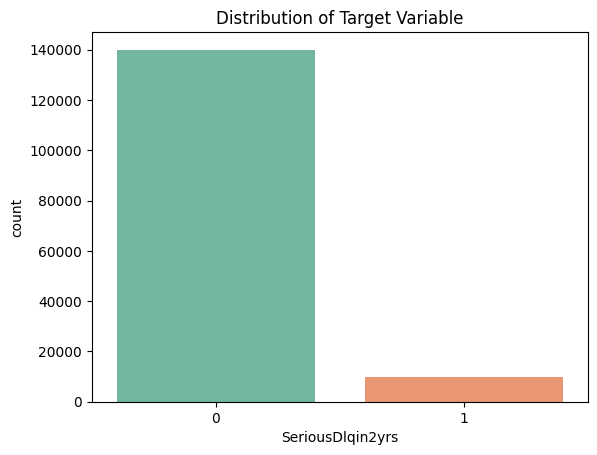

In [8]:
# Check target variable distribution
print("\Target variable distribution:", df['SeriousDlqin2yrs'].value_counts(), sep="\n")
print("\nTarget variable distribution (percentage):", df['SeriousDlqin2yrs'].value_counts(normalize=True)*100, sep="\n")

sns.countplot(x='SeriousDlqin2yrs', data=df, palette='Set2',)
plt.title("Distribution of Target Variable")
plt.show()

The dataset is **highly imbalanced** — 93.3% of borrowers did not 
default, while only 6.7% did. This imbalance means a naive model 
could achieve 93% accuracy simply by predicting "no default" for 
everyone, which would be misleading.

This class imbalance will be addressed during model training using 
techniques such as `class_weight='balanced'` or SMOTE oversampling.

### 2.5 Check for Outliers

A systematic IQR-based check is applied across all features to 
identify extreme values. Boxplots provide a visual overview, 
followed by a treatment decision for each affected feature.

In [9]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((df < (Q1 - 1.5 * IQR)) | 
            (df > (Q3 + 1.5 * IQR)))

outliers.sum()

SeriousDlqin2yrs                        10026
RevolvingUtilizationOfUnsecuredLines      763
age                                        46
NumberOfTime30-59DaysPastDueNotWorse    23982
DebtRatio                               31311
MonthlyIncome                            4879
NumberOfOpenCreditLinesAndLoans          3980
NumberOfTimes90DaysLate                  8338
NumberRealEstateLoansOrLines              793
NumberOfTime60-89DaysPastDueNotWorse     7604
NumberOfDependents                      13336
dtype: int64

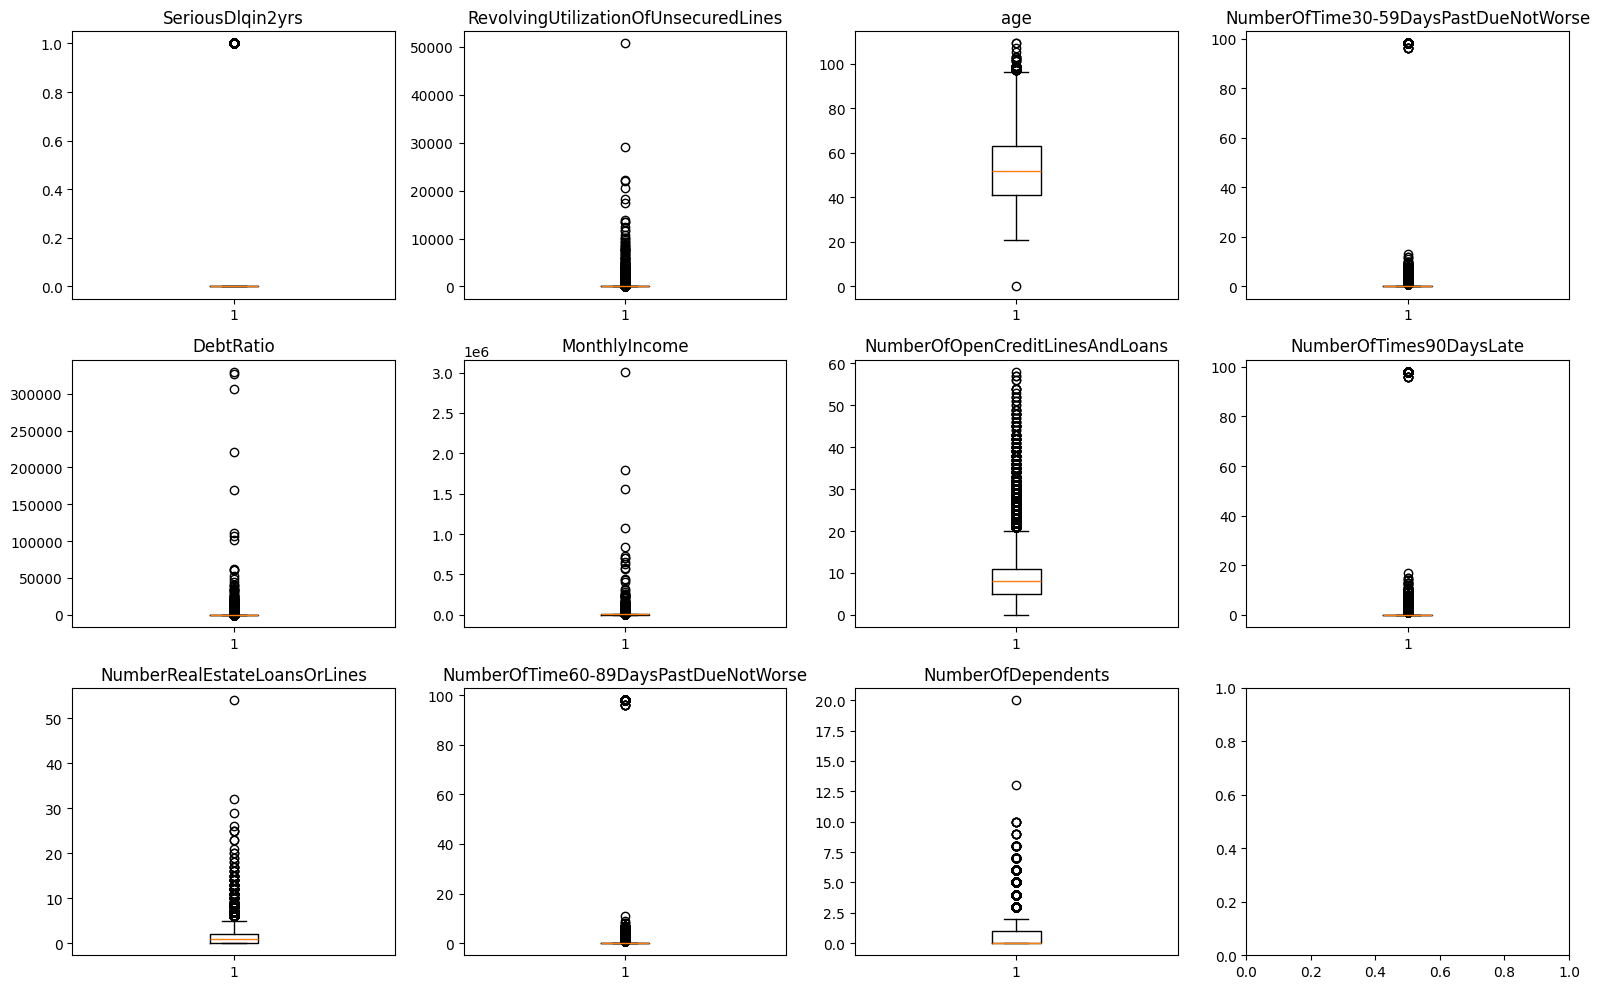

In [10]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### Outlier Treatment Summary

| Feature | Issue | Treatment |
|---|---|---|
| `age` | Contains age = 0, which is biologically impossible | Remove rows where age = 0 |
| `RevolvingUtilizationOfUnsecuredLines` | Values exceed 1 (max ~50,000), which is theoretically impossible for a utilization rate | Cap at 1 |
| `DebtRatio` | Extreme values exceeding 300,000, inconsistent with real financial behaviour | Cap at 99th percentile |
| `MonthlyIncome` | Highly right-skewed distribution with extreme high values | Apply log transformation |
| `NumberOfTime30-59DaysPastDueNotWorse` | High values present, but reflect real repeated delinquency behaviour | Retained — extreme counts are plausible |
| `NumberOfTimes90DaysLate` | Same as above | Retained — extreme counts are plausible |
| `NumberOfTime60-89DaysPastDueNotWorse` | Same as above | Retained — extreme counts are plausible |
| `NumberOfOpenCreditLinesAndLoans` | High values present, but a person can legitimately hold many credit lines | Retained |
| `NumberRealEstateLoansOrLines` | High values present, but multiple property loans are possible | Retained |
| `NumberOfDependents` | Max value of 20 is extreme but not impossible | Retained |

> **Note:** `SeriousDlqin2yrs` shows 10,026 flagged outliers under IQR method.
> This is not a true outlier issue — it reflects class imbalance in the target variable
> (minority class = defaulted borrowers). This will be addressed during model training.

### 2.6 Feature vs Target Comparison

Comparing mean feature values between defaulted and non-defaulted borrowers reveals which variables differ most between the two groups.

In [11]:
df.groupby('SeriousDlqin2yrs').mean()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
SeriousDlqin2yrs,,,,,,,,,,
0,6.168855,52.751375,0.280109,357.151168,6747.837774,8.493620,0.135225,1.020368,0.126666,0.743417
1,4.367282,45.926591,2.388490,295.121066,5630.826493,7.882306,2.091362,0.988530,1.828047,0.948208


Comparing the mean values of each feature between defaulted and 
non-defaulted borrowers reveals several key patterns:

- **Age**: Defaulters are on average ~7 years younger (45.9 vs 
  52.8), suggesting younger borrowers carry higher risk.
- **MonthlyIncome**: Defaulters have lower average income, 
  indicating financial stress as a contributing factor.
- **Delinquency counts**: All three past-due features are 
  significantly higher for defaulters, confirming that past 
  delinquency behaviour is a strong predictor of future default.
- **NumberOfDependents**: Defaulters have slightly more dependents 
  on average, which may indicate higher financial obligations.

These patterns suggest that **past delinquency behaviour, age, and 
income** are likely to be the most important predictors in the model.

### 2.7 Distribution Plots

Overlapping histograms compare the feature distributions of defaulted vs non-defaulted borrowers across all features.

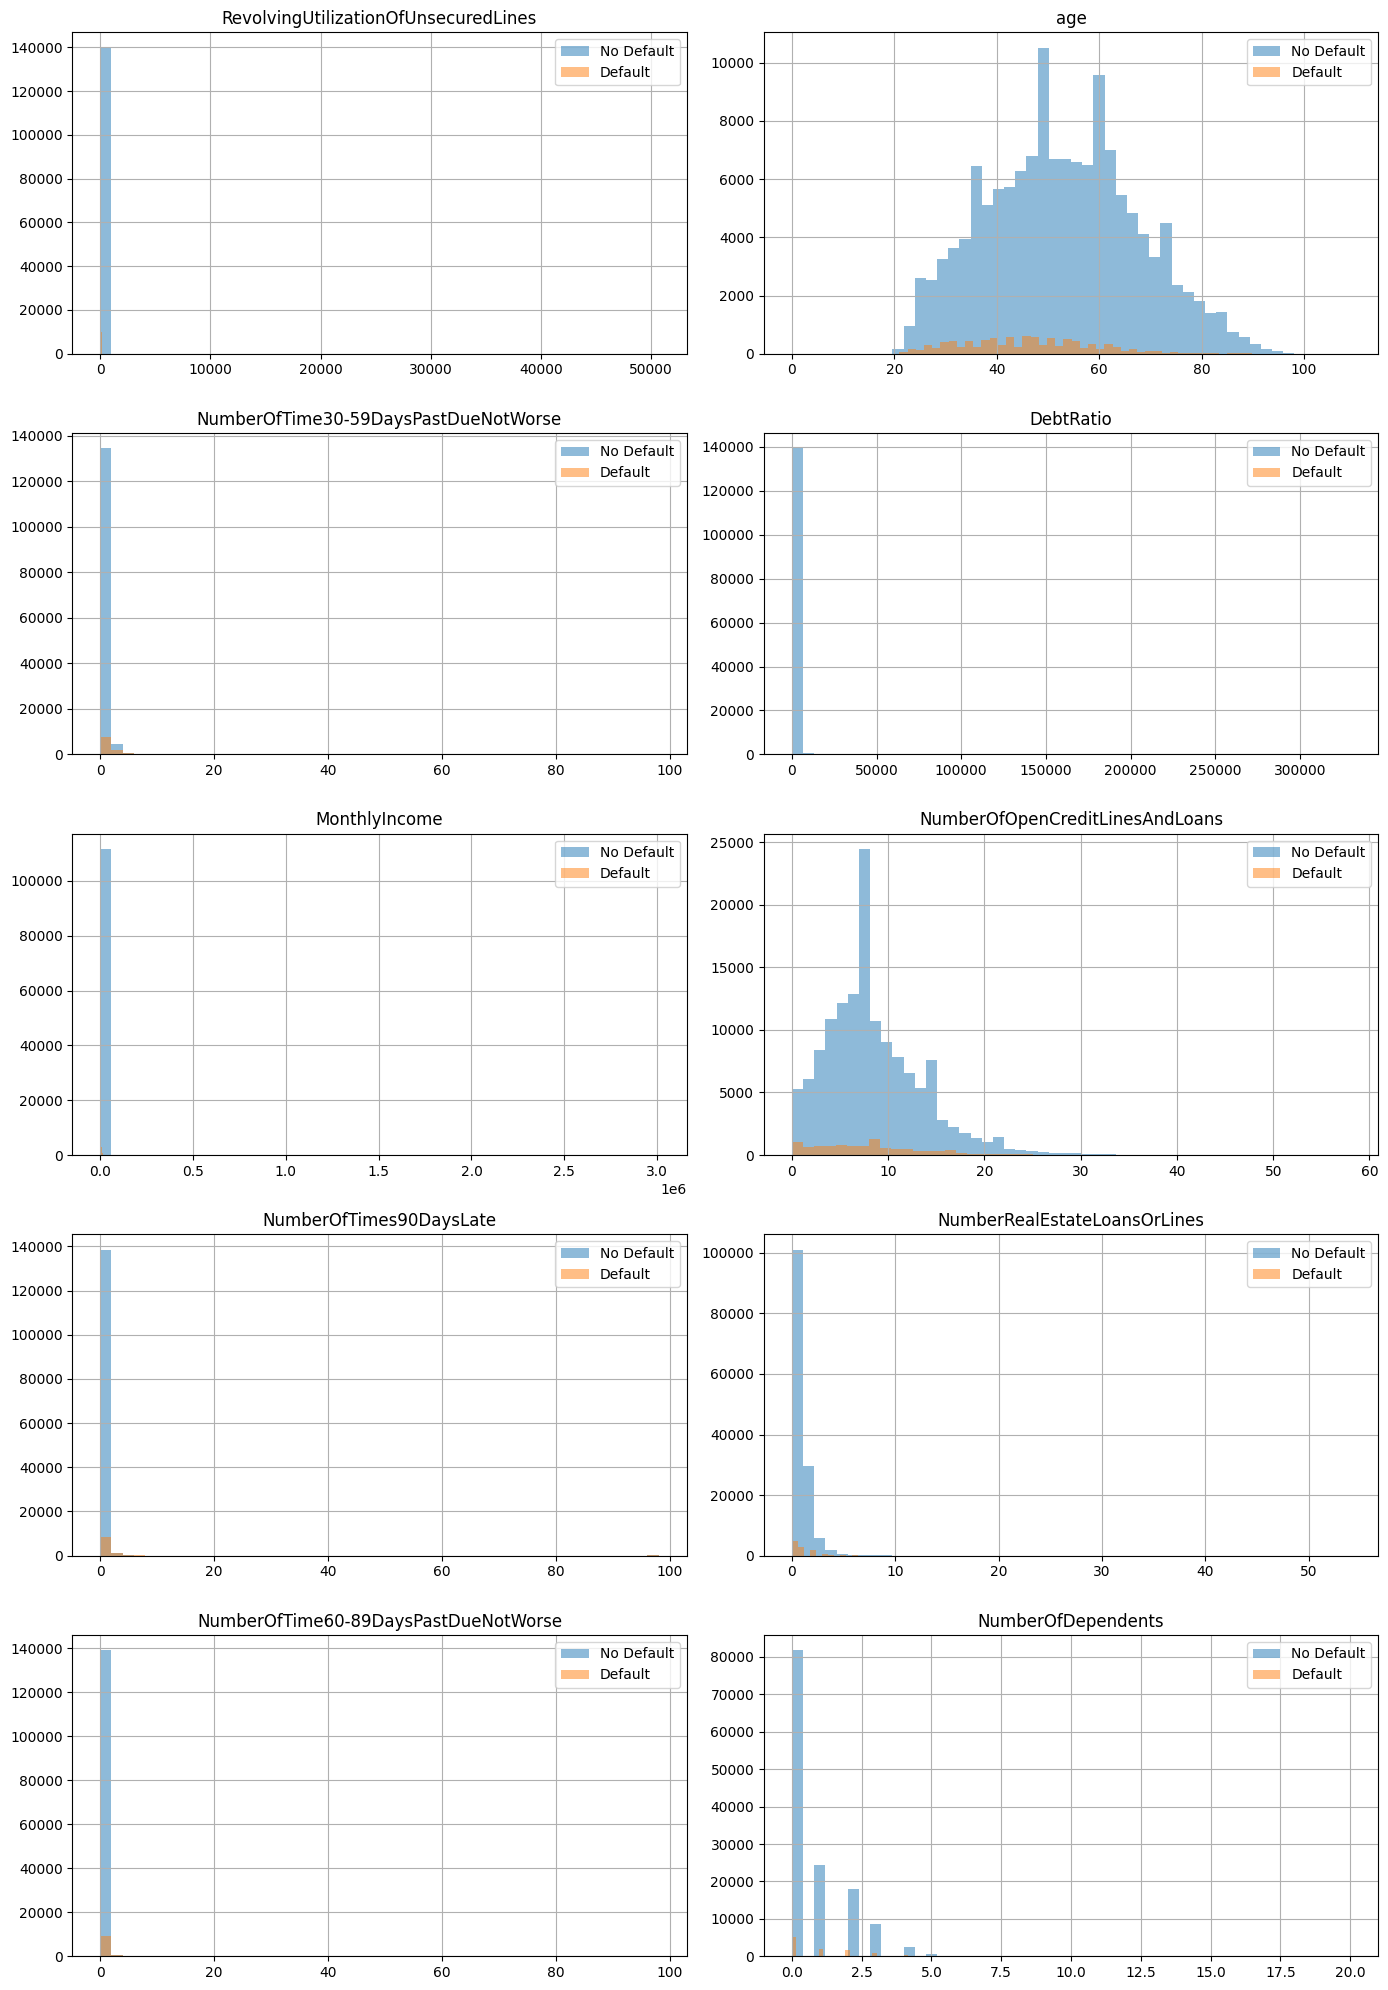

In [12]:
features = [col for col in df.columns if col != 'SeriousDlqin2yrs']

n = len(features)
fig, axes = plt.subplots((n+1)//2, 2, figsize=(14, n*2))
axes = axes.flatten()

for i, feat in enumerate(features):
    df[df['SeriousDlqin2yrs']==0][feat].hist(
        ax=axes[i], alpha=0.5, label='No Default', bins=50)
    df[df['SeriousDlqin2yrs']==1][feat].hist(
        ax=axes[i], alpha=0.5, label='Default', bins=50)
    axes[i].set_title(feat)
    axes[i].legend()

plt.tight_layout()
plt.show()

### 2.8 Correlation Matrix

A heatmap of pairwise correlations helps identify which features are most associated with the target variable, and whether any features are highly correlated with each other (multicollinearity).

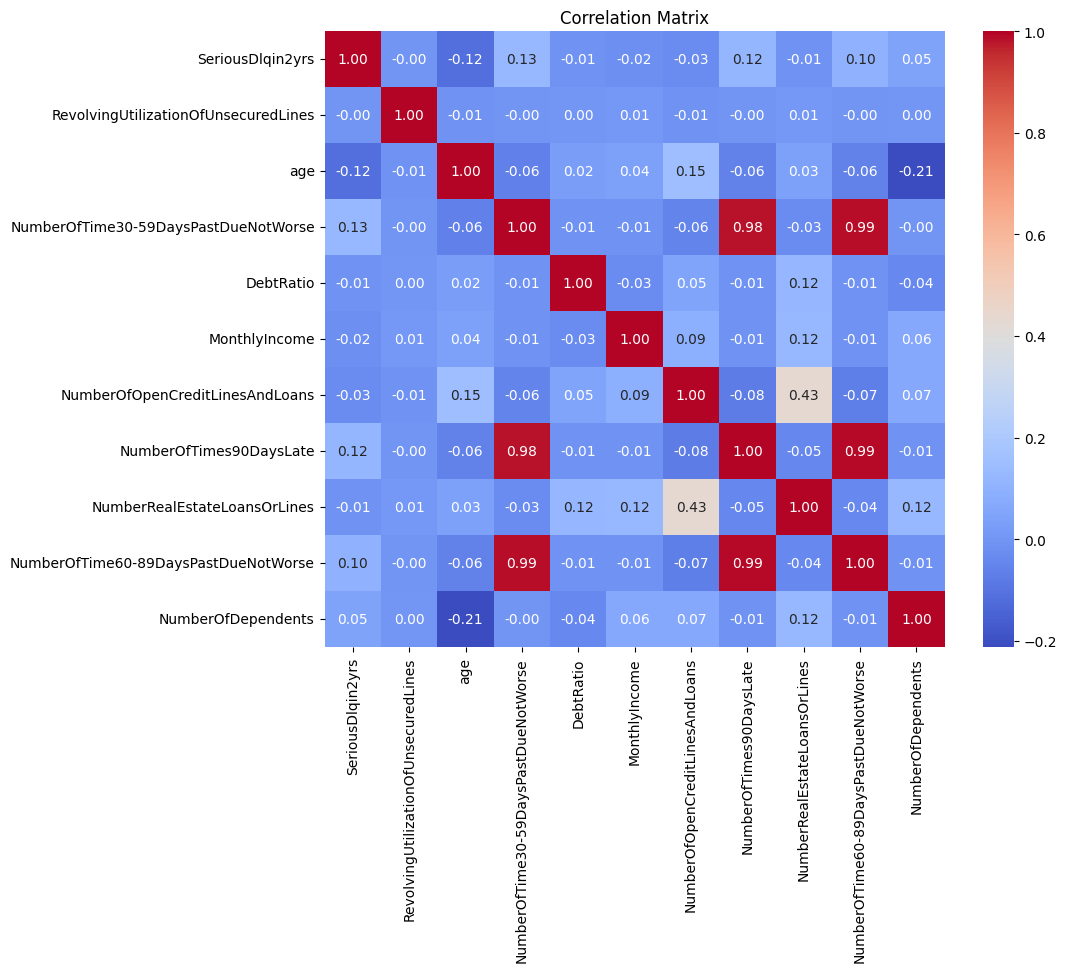

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Key findings from the correlation matrix:

- The three delinquency features (`NumberOfTime30-59DaysPastDueNotWorse`, 
  `NumberOfTimes90DaysLate`, `NumberOfTime60-89DaysPastDueNotWorse`) 
  are **highly correlated with each other** (r > 0.9). This indicates 
  multicollinearity — keeping all three may not add predictive value 
  and could affect model stability. This will be reviewed during 
  feature selection.
- `RevolvingUtilizationOfUnsecuredLines` and the delinquency features 
  show the **strongest positive correlation** with `SeriousDlqin2yrs`.
- `age` shows a **negative correlation** with the target — older 
  borrowers are less likely to default.
- `MonthlyIncome` shows a **weak negative correlation** with default, 
  consistent with the group mean analysis above.

## 3. EDA Summary & Next Steps

### Key Findings
- Dataset contains 150,000 records with no categorical features
- **Missing values**: `MonthlyIncome` (19.8%) and 
  `NumberOfDependents` (2.6%) require imputation
- **Duplicate rows**: 609 exact duplicates to be removed
- **Class imbalance**: Only 6.7% positive class — must be addressed 
  in modeling
- **Outliers**: Several features contain extreme values requiring 
  treatment (see Outlier Treatment Summary above)
- **Multicollinearity**: The three delinquency count features are 
  highly correlated — consider feature selection

### Preprocessing Actions Required
1. Remove 609 duplicate rows
2. Remove rows where `age = 0`
3. Cap `RevolvingUtilizationOfUnsecuredLines` at 1
4. Cap `DebtRatio` at 99th percentile
5. Apply log transformation to `MonthlyIncome`
6. Impute missing values in `MonthlyIncome` and `NumberOfDependents`
7. Apply train/test split (80/20)
8. Address class imbalance during model training